In [1]:
## automatically reload 
%reload_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import NEOfaster as nf
import NEOMOD3 as nm3
import neoom as no
import importlib
importlib.reload(nf)
importlib.reload(no)

<module 'neoom' from '/astro/users/ds2004/digest3/neoom.py'>

In [3]:
from astroquery.imcce import Skybot
from astropy.coordinates import SkyCoord
from astropy.time import Time
import astropy.units as u
field = SkyCoord(0*u.deg, 0*u.deg)
epoch = Time('2025-09-23 00:00', format='iso')
Skybot.cone_search(field, 5*u.arcmin, epoch)


Number,Name,RA,DEC,Type,V,posunc,centerdist,RA_rate,DEC_rate,geodist,heliodist,alpha,elong,x,y,z,vx,vy,vz,epoch
,,deg,deg,,mag,arcsec,arcsec,arcsec / h,arcsec / h,AU,AU,deg,deg,AU,AU,AU,AU / d,AU / d,AU / d,d
int64,str10,float64,float64,str8,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
--,2019 NC114,359.9844545833333,-0.07309388888888889,MB>Outer,21.6,38.118,269.024,-28.2474,-12.025,1.71976855688,2.71954272873,0.03,179.9,2.720650001,-0.017464295,-0.009629809,0.001822749,0.010078593,0.004411208,2460940.0


In [4]:
da = pd.read_hdf("s3m_orbits.h5")
db = pd.read_hdf("s3m_colors.h5")

df = pd.merge(da, db, on="ObjID", how="inner")

print(df.shape)
print(df.head())


(11107420, 16)
       ObjID FORMAT        q        e       inc       node    argPeri  \
0  S1000000a    COM  3.01822  0.05208  22.56035  211.00286  335.42134   
1  S1000001a    COM  2.10974  0.07518   4.91571  209.40298  322.66447   
2  S1000002a    COM  2.80523  0.07777   1.24945  112.52284  139.86858   
3  S1000003a    COM  2.10917  0.13219   1.46615  266.54621  232.24412   
4  S1000007a    COM  1.98262  0.16324  23.42404  210.02222  326.18514   

   t_p_MJD_TDB  epochMJD_TDB        H_r       u-r       g-r       i-r  \
0  51575.94061       54800.0  13.924627  1.294360  0.622381 -0.434550   
1  54205.77161       54800.0  20.214435  1.590819  0.778033 -0.483086   
2  54468.71747       54800.0  14.378583  1.219277  0.603353 -0.434341   
3  54212.16304       54800.0  19.320075  1.247467  0.594347 -0.452751   
4  54730.97656       54800.0   7.806269  1.730318  0.809627 -0.488813   

        z-r       y-r    GS  
0 -0.721692 -0.946406  0.15  
1 -0.734472 -0.910685  0.15  
2 -0.736982 -0.94

In [5]:
df.columns

Index(['ObjID', 'FORMAT', 'q', 'e', 'inc', 'node', 'argPeri', 't_p_MJD_TDB',
       'epochMJD_TDB', 'H_r', 'u-r', 'g-r', 'i-r', 'z-r', 'y-r', 'GS'],
      dtype='object')

In [6]:
df["a"] = df["q"] / (1 - df["e"])


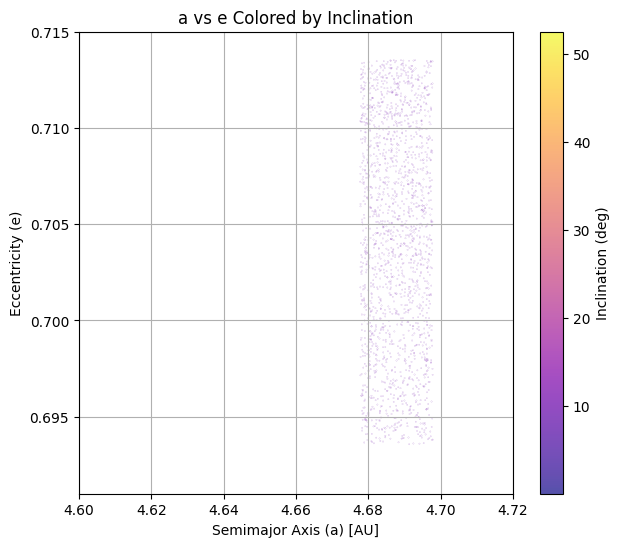

In [7]:

plt.figure(figsize=(7, 6))
sc = plt.scatter(df["a"], df["e"], c=df["inc"], cmap="plasma", s=0.01, alpha=0.7)
plt.xlabel("Semimajor Axis (a) [AU]")
plt.ylabel("Eccentricity (e)")
plt.title("a vs e Colored by Inclination")
plt.colorbar(sc, label="Inclination (deg)")
plt.grid(True)
plt.xlim(4.6,4.72)
plt.ylim(0.691, 0.715)
plt.show()


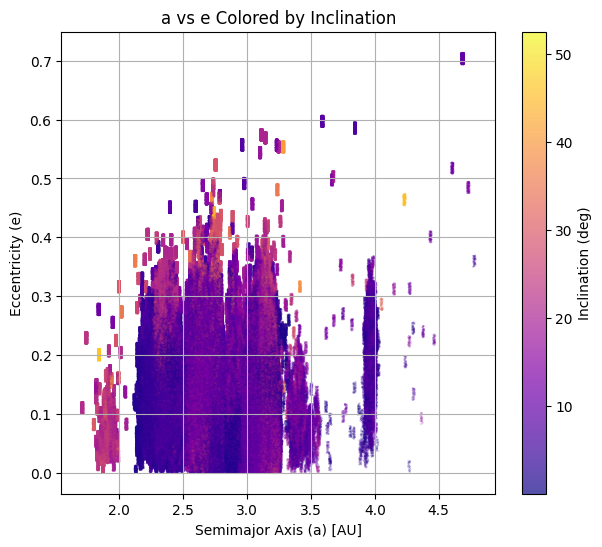

In [8]:

plt.figure(figsize=(7, 6))
sc = plt.scatter(df["a"], df["e"], c=df["inc"], cmap="plasma", s=0.01, alpha=0.7)
plt.xlabel("Semimajor Axis (a) [AU]")
plt.ylabel("Eccentricity (e)")
plt.title("a vs e Colored by Inclination")
plt.colorbar(sc, label="Inclination (deg)")
plt.grid(True)
plt.show()


array([[<Axes: title={'center': 'H_r'}>]], dtype=object)

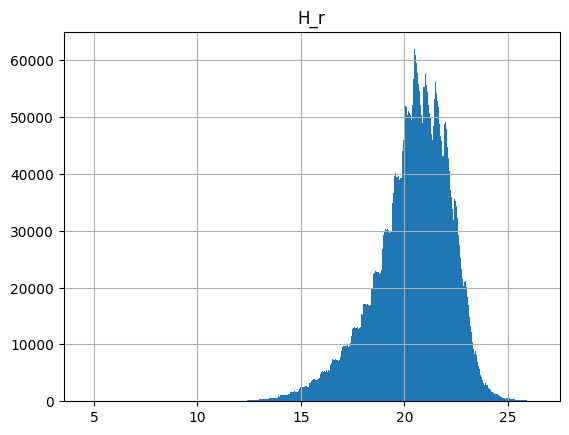

In [9]:
df.hist("H_r", bins="fd")

In [10]:

around_a = 0.1778
around_e = 0.1    


corner = df[
    (df["a"] > 4.5 - around_a) & (df["a"] < 4.5 + around_a) & # so bw a = 4.3222 to 4.6778
    (df["e"] > 0.7 - around_e) & (df["e"] < 0.7 + around_e) # bw e = 0.6 to e = 0.8
]

# if i go above 0.1778 to 0.1779 the number of  object increase so the lowest val is 0.1778?
print("Objects near a = 4.5, e = 0.7:", len(corner))
print(corner[["ObjID", "a", "e", "inc", "H_r"]].head())


Objects near a = 4.5, e = 0.7: 1
              ObjID         a        e       inc        H_r
11097752  S1095AjQa  4.677755  0.70721  10.45431  25.367649


In [11]:
# defining the min/max values for a,e,i,H
a_min = df["a"].min()
a_max = df["a"].max()
e_min = df["e"].min()
e_max = df["e"].max()
i_min = df["inc"].min()
i_max = df["inc"].max()
H_min = df["H_r"].min()
H_max = df["H_r"].max()


In [12]:

print("Min a:", a_min) # so could do binning like 
print("Max a:", a_max)

print("Min e:", e_min)
print("Max e:", e_max)

print("Min i:", i_min)
print("Max i:", i_max)

print("Min H (in r band):", H_min)
print("Max H (in r band):", H_max)

Min a: 1.6991927346115034
Max a: 4.789266853059957
Min e: 0.0
Max e: 0.71352
Min i: 2e-05
Max i: 52.49871
Min H (in r band): 4.624682005499606
Max H (in r band): 26.406205440749808


In [13]:
n_H, n_a, n_e, n_i = 52,42,25,22
#n_H, n_a, n_e, n_i = 152,142,125,122
#n_H, n_a, n_e, n_i = 352,342,325,322
points = np.vstack([df["H_r"], df["a"], df["e"], df["inc"]]).T


edges = [
    np.linspace(H_min, H_max, n_H + 1),
    np.linspace(a_min, a_max, n_a + 1),
    np.linspace(e_min, e_max, n_e + 1),
    np.linspace(i_min, i_max, n_i + 1)
]


array4D, edges_out = np.histogramdd(points, bins=edges)

print("array4D shape:", array4D.shape)
print("Total count in array:", array4D.sum())


array4D shape: (52, 42, 25, 22)
Total count in array: 11107420.0


In [14]:
H_edges = edges_out[0]
a_edges = edges_out[1]
e_edges = edges_out[2]
i_edges = edges_out[3]


H_center = 0.5 * (H_edges[1:] + H_edges[:-1])
a_center = 0.5 * (a_edges[1:] + a_edges[:-1])
e_center = 0.5 * (e_edges[1:] + e_edges[:-1])
i_center = 0.5 * (i_edges[1:] + i_edges[:-1])



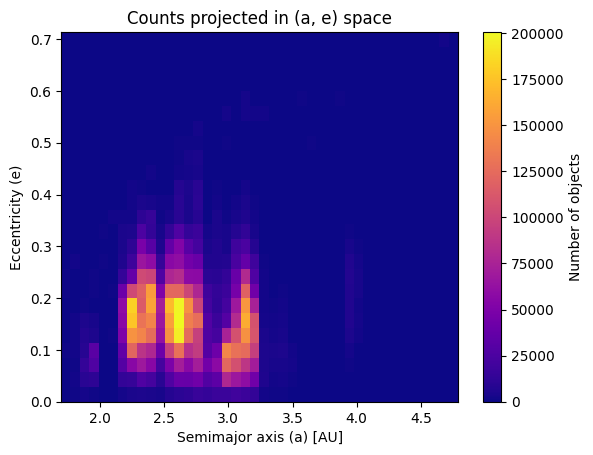

In [15]:

K_ae = array4D.sum(axis=(0, 3))        


plt.imshow(K_ae.T,
           extent=[a_min, a_max, e_min, e_max],
           origin="lower", aspect="auto", cmap="plasma")
plt.xlabel("Semimajor axis (a) [AU]")
plt.ylabel("Eccentricity (e)")
plt.title("Counts projected in (a, e) space")
plt.colorbar(label="Number of objects")
plt.show()


In [16]:
obstime_str="2025-09-23T00:00:00"
#ra_deg, dec_deg, dra_deg_per_day, ddec_deg_per_day = 186.35, -5.0, 46.27, -19.0
ra_deg, dec_deg, dra_deg_per_day, ddec_deg_per_day = 359.9, -0.07, -0.188316, -0.08016
# add mag here
mag = 21.0
# anti-Sun at Sep 23 = equinox so RA = 0, Dec = 0
ra0_deg, dec0_deg = 0.0, 0.0

l_hat, v_hat = nf.compute_unit_vectors(ra_deg, dec_deg, dra_deg_per_day, ddec_deg_per_day)
obstime, rE, vE, r_obs = nf.get_earth_and_observer(obstime_str) 

In [17]:
from matplotlib.colors import TwoSlopeNorm


d_vals = np.linspace(0.00, 4.00, 60)
v_vals = np.linspace(-20.0, 20.0, 120)

W = np.zeros((len(d_vals), len(v_vals)))
A = np.zeros_like(W)
E = np.zeros_like(W)
I = np.zeros_like(W)
H = np.zeros_like(W)


for i, d in enumerate(d_vals):
    for j, v in enumerate(v_vals):
        w, a, e, inc, H_0 = nf.compute_neomod3_weight(
            d, v, l_hat, v_hat, mag, obstime, rE, vE, r_obs,
            array4D, H_center, a_center, e_center, i_center  
        )
        W[i, j] = w
        A[i, j] = a
        E[i, j] = e
        I[i, j] = inc
        H[i, j] = np.asarray(H_0).squeeze()


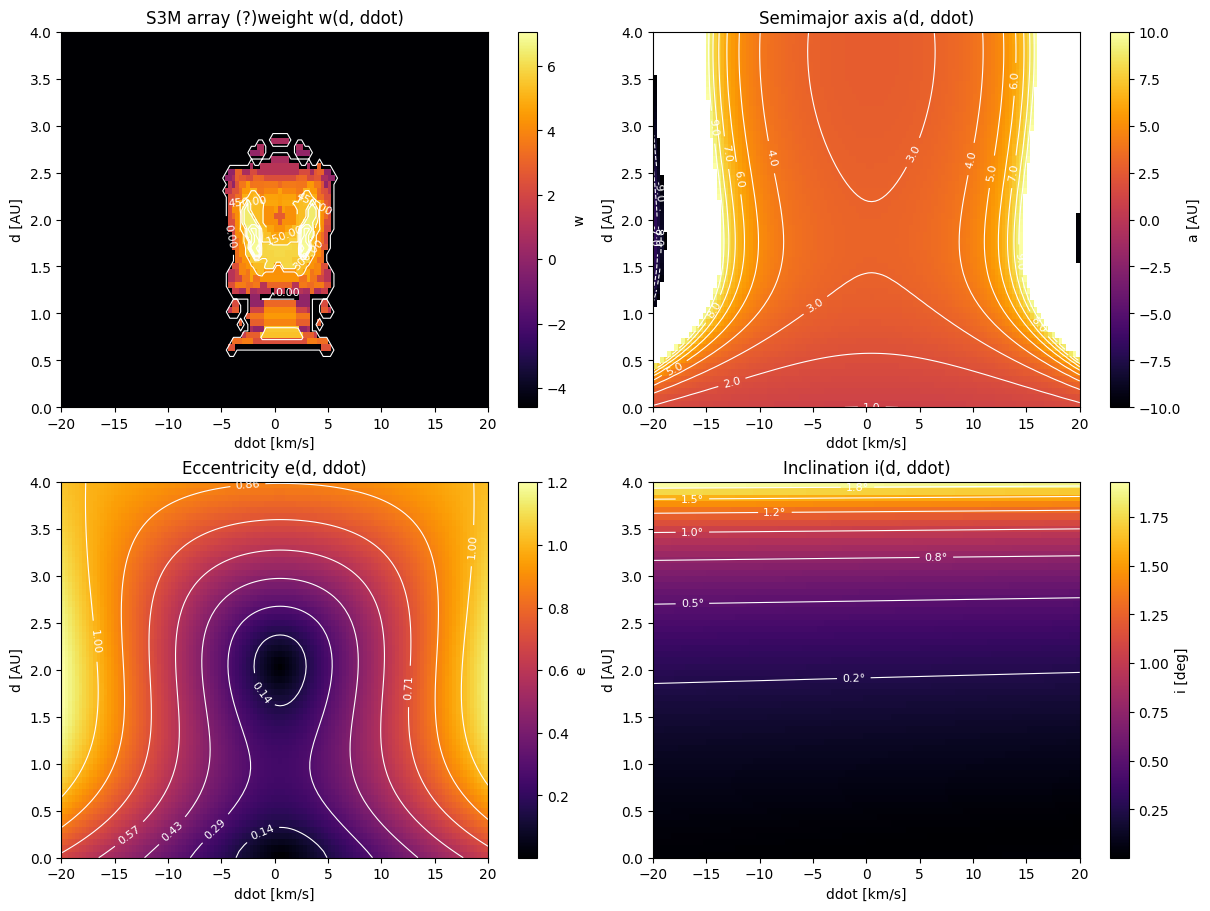

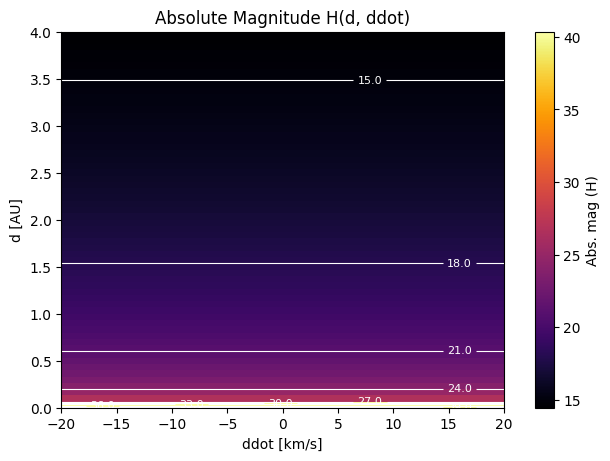

In [18]:
extent = [v_vals.min(), v_vals.max(), d_vals.min(), d_vals.max()]  # x=ddot, y=d
X, Y = np.meshgrid(v_vals, d_vals, indexing="xy")

fig, axs = plt.subplots(2, 2, figsize=(12, 9), constrained_layout=True)

# weight
im0 = axs[0, 0].imshow(np.log(W + 1e-2), origin="lower", extent=extent, aspect="auto", cmap="inferno")
c0  = axs[0, 0].contour(X, Y, W, levels=8, colors="white", linewidths=0.8)
axs[0, 0].clabel(c0, inline=True, fontsize=8, fmt="%.2f")
axs[0, 0].set(title="S3M array (?)weight w(d, ddot)", xlabel="ddot [km/s]", ylabel="d [AU]")
fig.colorbar(im0, ax=axs[0, 0], label="w")

# semimajor axis
A_mask = np.ma.masked_where(~np.isfinite(A) | (np.abs(A) > 10), A)
norm = TwoSlopeNorm(vmin=-10, vcenter=0, vmax=10)
im1 = axs[0, 1].imshow(A_mask, origin="lower", extent=extent, aspect="auto", cmap="inferno", norm=norm)
cs1 = axs[0, 1].contour(X, Y, A_mask, levels=np.linspace(-10, 10, 21), colors="white", linewidths=0.8)
axs[0, 1].clabel(cs1, inline=True, fontsize=8, fmt="%.1f")
axs[0, 1].set(title="Semimajor axis a(d, ddot)", xlabel="ddot [km/s]", ylabel="d [AU]")
fig.colorbar(im1, ax=axs[0, 1], label="a [AU]")

# eccentricity
im2 = axs[1, 0].imshow(E, origin="lower", extent=extent, aspect="auto", cmap="inferno")
cs2 = axs[1, 0].contour(X, Y, E, levels=np.linspace(0, 1, 8), colors="white", linewidths=0.8)
axs[1, 0].clabel(cs2, inline=True, fontsize=8, fmt="%.2f")
axs[1, 0].set(title="Eccentricity e(d, ddot)", xlabel="ddot [km/s]", ylabel="d [AU]")
fig.colorbar(im2, ax=axs[1, 0], label="e")

# inclination
im3 = axs[1, 1].imshow(I, origin="lower", extent=extent, aspect="auto", cmap="inferno")
cs3 = axs[1, 1].contour(X, Y, I, levels=8, colors="white", linewidths=0.8)
axs[1, 1].clabel(cs3, inline=True, fontsize=8, fmt="%.1f°")
axs[1, 1].set(title="Inclination i(d, ddot)", xlabel="ddot [km/s]", ylabel="d [AU]")
fig.colorbar(im3, ax=axs[1, 1], label="i [deg]")

plt.show()

# H panel
figH, axH = plt.subplots(figsize=(6, 4.5), constrained_layout=True)
imH = axH.imshow(H, origin="lower", extent=extent, aspect="auto", cmap="inferno")
csH = axH.contour(X, Y, H, levels=8, colors="white", linewidths=0.8)
axH.clabel(csH, inline=True, fontsize=8, fmt="%.1f")
axH.set(title="Absolute Magnitude H(d, ddot)", xlabel="ddot [km/s]", ylabel="d [AU]")
figH.colorbar(imH, ax=axH, label="Abs. mag (H)")
plt.show()


In [19]:

l_hat, v_hat = no.compute_unit_vectors(ra_deg, dec_deg, dra_deg_per_day, ddec_deg_per_day)
obstime, rE, vE, r_obs = no.get_earth_and_observer(obstime_str) 
neo_score, a, e, i = no.compute_neomod3_weight(0.2, 3.0, l_hat, v_hat, obstime, rE, vE, r_obs, array4D, H_center, a_center, e_center, i_center)
# me when i center??



print("neo_score:", neo_score)
print("a:", a)
print("e:", e)
print("i:", i)

neo_score: 0.0
a: 1.3379555194348156
e: 0.1327648130516081
i: 0.01203348925939648


In [20]:


def comp_sum1():
    
    N_rate = 51          #2 mins 30 sec, for 31 = 4 mins 20 sec so around 50 mins for 101 --> 1 min 40 s for 31
    vlam_min, vlam_max = -0.6, 0.6
    vbet_min, vbet_max = -0.6, 0.6

    vlam_vals  = np.linspace(vlam_min, vlam_max, N_rate)
    vbet_vals = np.linspace(vbet_min, vbet_max, N_rate)
    vlam_deg_day = 0.12
    vbeta_deg_day = 0.22
    

    
    
    K = np.zeros((len(vlam_vals), len(vbet_vals)), dtype=float)
    
    for i,vlam in enumerate(vlam_vals):
        for j,vbet in enumerate(vbet_vals):
            dra, ddec = no. ecliptic_rates_to_radec_rates(ra0_deg, dec0_deg, vlam, vbet)
            w_int = no.weight_marginalized_over_d_and_ddot(array4D=array4D, H_center=H_center, a_center=a_center, e_center=e_center, i_center=i_center,
                                                        ra_deg=ra0_deg, dec_deg=dec0_deg, dra_deg_per_day=dra, ddec_deg_per_day=ddec,obstime_str=obstime_str
                                                        )
            

            K[j, i] = w_int
            #print(w_int, dra, ddec)
        #break
    extent = [vlam_vals[0], vlam_vals[-1], vbet_vals[0], vbet_vals[-1]]
    return K, extent

K, extent= comp_sum1()



/tmp/ipykernel_1782305/3546784570.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  my_viridis = cm.get_cmap("viridis", 1024).with_extremes(under="white")


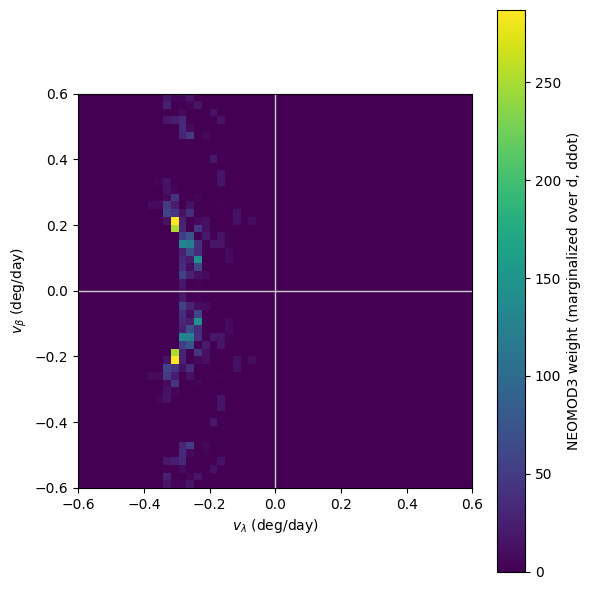

In [21]:
# VERSION WITH FLIPPED DRA VLAMBDA
from matplotlib import cm
plt.figure(figsize=(6.0, 6.0))
 
my_viridis = cm.get_cmap("viridis", 1024).with_extremes(under="white")
im = plt.imshow(K, origin="lower", extent=extent, cmap=my_viridis, aspect="equal")


plt.colorbar(label="NEOMOD3 weight (marginalized over d, ddot)")

plt.axhline(0, color="0.8", lw=1)
plt.axvline(0, color="0.8", lw=1)
plt.xlabel(r"$v_\lambda$ (deg/day)")
plt.ylabel(r"$v_\beta$ (deg/day)")
plt.tight_layout()
plt.show()



In [22]:
# setting value for phi = 0, beta = 0 
phi_deg = 0.0 # on the opposition
beta_deg = 0.0 # on the ecliptic


In [23]:
vE_deg_per_day = 0.986  # earth's orbital speed

def prediction_vlam_vbet(R_au, i_deg, phi_deg, beta_deg=0.0):
    # convert angles to radians
    i = np.deg2rad(i_deg)
    phi = np.deg2rad(phi_deg)
    beta = np.deg2rad(beta_deg)
    
    # from eqn A7 to A8
    theta = phi - np.arcsin(np.sin(phi) / R_au)
    Delta = np.sqrt(R_au**2 + 1.0 - 2.0 * R_au * np.cos(theta))
    
    # heliocentric velocity components 
    v_factor = vE_deg_per_day / np.sqrt(R_au)
    vx = v_factor * np.cos(i) * np.sin(theta)
    vy = v_factor * np.cos(i) * np.cos(theta)
    vz = v_factor * np.sin(i)
    
    # ecliptic rates
    vlam =  (np.sin(phi) * vx + np.cos(phi) * (vy - vE_deg_per_day)) / Delta
    
    vbet = (-np.sin(beta) * np.cos(phi) * vx
            + np.sin(beta) * np.sin(phi) * (vy - vE_deg_per_day)
            + np.cos(beta) * vz) / Delta
    
    return vlam, vbet


In [24]:
i_list = np.arange(-10.0, 15.0, 5.0)  # -10, -5, 0, 5, 10
R_vals = np.linspace(1.5, 4.5, 800)  # AU 

i_lines = []  # [vlam_arr, vbet_arr, i_deg]

for i_deg in i_list:
    vlam_arr = []
    vbet_arr = []
    for R in R_vals:
        vlam, vbet = prediction_vlam_vbet(R, i_deg, phi_deg, beta_deg)
        vlam_arr.append(vlam)
        vbet_arr.append(vbet)
    i_lines.append((np.array(vlam_arr), np.array(vbet_arr), i_deg))


In [25]:
R_list = [2.0, 2.5, 3.0, 3.5]
i_pos = i_center[(i_center >= 0.0) & (i_center <= 40.0)]  # same i-range as neomod3
i_vals_for_R = np.concatenate((-i_pos[::-1], i_pos))
R_lines = []  # [vlam_arr, vbet_arr, R]
for R in R_list:
    vlam_arr = []
    vbet_arr = []
    for i_deg in i_vals_for_R:
        vlam, vbet = prediction_vlam_vbet(R, i_deg, phi_deg, beta_deg)
        vlam_arr.append(vlam)
        vbet_arr.append(vbet)
    R_lines.append((np.array(vlam_arr), np.array(vbet_arr), R))


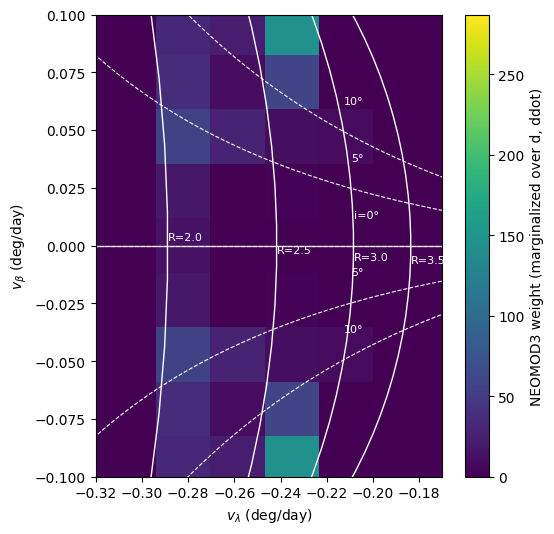

In [26]:
plt.figure(figsize=(6.0, 6.0))
im = plt.imshow(K, origin="lower", extent=extent, cmap="viridis", aspect="equal")
plt.colorbar(label="NEOMOD3 weight (marginalized over d, ddot)")
plt.axhline(0, color="0.8", lw=1)
plt.axvline(0, color="0.8", lw=1)
plt.xlabel(r"$v_\lambda$ (deg/day)")
plt.ylabel(r"$v_\beta$ (deg/day)")
plt.xlim(-0.32, -0.17)
plt.ylim(-0.1, 0.1)

# solid lines for R
for vlam_arr, vbet_arr, R in R_lines:
    plt.plot(vlam_arr, vbet_arr, color="white", lw=1.0)
    idx = len(vlam_arr) // 2
    plt.text(vlam_arr[idx], vbet_arr[idx] - 0.012,  # a bit below the line
             f"R={R:.1f}", color="white", fontsize=8)

# dashed lines for i
for vlam_arr, vbet_arr, i_deg in i_lines:
    plt.plot(vlam_arr, vbet_arr, color="white", lw=0.8, ls="--")
    idx = len(vlam_arr) // 2
    plt.text(vlam_arr[idx], vbet_arr[idx] + 0.012,
             f"{abs(i_deg):.0f}°" if i_deg != 0 else "i=0°",
             color="white", fontsize=8)